In [31]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

print("NumPy Version :{}".format(np.__version__))
print("TensorFlow Version :{}".format(tf.__version__))
print("Matplotlib Version :{}".format(plt.matplotlib.__version__))

NumPy Version :2.1.3
TensorFlow Version :2.20.0
Matplotlib Version :3.10.0


input과 label

In [32]:
x_input = tf.constant([
    # [공부시간, 수면시간]
    [1, 4],
    [2, 5],
    [2, 7],
    [3, 4],
    [3, 6],
    [4, 5],
    [4, 7],
    [5, 4],
    [5, 6],
    [6, 5],
    [6, 7],
    [7, 6],
    [7, 8],
    [8, 5],
    [8, 7],
    [9, 6],
    [9, 8]
], dtype=tf.float32)
labels = tf.constant([
    # [불합격, 보통, 우수]
    [1, 0, 0],  # [1,4]  → 불합격
    [1, 0, 0],  # [2,5]  → 불합격
    [0, 1, 0],  # [2,7]  → 보통
    [1, 0, 0],  # [3,4]  → 불합격
    [0, 1, 0],  # [3,6]  → 보통
    [0, 1, 0],  # [4,5]  → 보통
    [0, 1, 0],  # [4,7]  → 보통
    [0, 1, 0],  # [5,4]  → 보통
    [0, 1, 0],  # [5,6]  → 보통
    [0, 1, 0],  # [6,5]  → 보통
    [0, 0, 1],  # [6,7]  → 우수
    [0, 0, 1],  # [7,6]  → 우수
    [0, 0, 1],  # [7,8]  → 우수
    [0, 0, 1],  # [8,5]  → 우수
    [0, 0, 1],  # [8,7]  → 우수
    [0, 0, 1],  # [9,6]  → 우수
    [0, 0, 1]   # [9,8]  → 우수
], dtype=tf.float32)

min,max scaler

In [33]:
x_input_org = x_input # 입력 원본 데이터 저장
x_min,x_max = np.min(x_input,axis = 0),np.max(x_input,axis = 0)
x_input = (x_input-x_min)/(x_max-x_min) # min-max scaling을 이용해서 입력데이터들의 스케일을 비슷하게 맞추자

모델 정의

In [34]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape = (2,)), # 입력은 2개구나
    tf.keras.layers.Dense(3, activation= 'softmax') # 출력 3개, 근데 softmax(출력의 값의 합 = 1)를 거치고 값을 반환하자
])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 3)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

compile

In [35]:
model.compile(
    optimizer = tf.keras.optimizers.SGD(learning_rate = 0.1), # loss를 줄이기위해 가중치(weight) 어떻게 수정할까? -> 경사하강법 (현재 기울기을 보고 가중치를 learning_rate만큼 움직이자)
    loss = 'categorical_crossentropy', # 모델의 예측과 얼마나 다른지 어떤 방식으로 보여줄까? -> one-hot 형태로 보여줘
    metrics = ['accuracy'] # 학습을 잘하고있는지를 어떻게 보여줄까? -> 정확도
)

training

In [36]:
%%time
#주피터에서 사용하는 명령어로 해당 코드가 실행되는데 걸린시간을 측정하는 명령어
history = model.fit(x_input,labels,epochs = 1000) # input데이터랑 labels 이용해서 학습해보자 , epochs는 학습 횟수 / model.fit(): = 학습실

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.4118 - loss: 1.0839
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.4118 - loss: 1.0727
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.4118 - loss: 1.0622
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.3529 - loss: 1.0526
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3529 - loss: 1.0436
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3529 - loss: 1.0352
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4118 - loss: 1.0274
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3529 - loss: 1.0201
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.3529 - loss: 1.0132
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4118 - loss: 1.0069
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.4118 - loss: 1.0009
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy

plot (그래프)

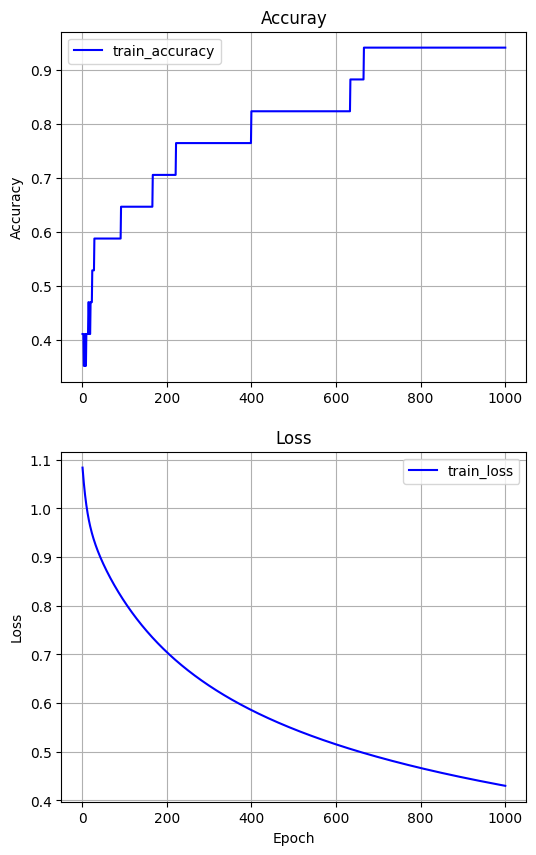

In [37]:
# accuray, loss 그래프 출력
loss = history.history['loss']
epochs = range(1, len(loss)+1)

plt.figure(figsize=(6, 10))
plt.subplot(2, 1, 1)
plt.title('Accuray')
plt.plot(epochs, history.history['accuracy'], 'b', label='train_accuracy')
plt.grid(True)
plt.ylabel('Accuracy')
plt.legend(loc='best')

plt.subplot(2, 1, 2)
plt.title('Loss')
plt.plot(epochs, history.history['loss'], 'b', label='train_loss')
plt.grid(True)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.show()

traing 결과 test

In [48]:
H_x = model.predict(x_input) # H_x 라고 이름 붙이는건 보통 hypothesis(가설)을 의미한다. / H(x) or h(x) => 예측함수
for x,h,l in zip(x_input_org,H_x,labels): # (x 원본데이터, 학습을 통해 나온 결과 , 원본 labels 데이터) 를 아래포멧에 맞추어 출력하자
  print("공부시간:{}, 수면시간:{} [label(불합격 0,보통 1,우수 2):{}]=>class:{} {}".format(x[0],x[1],np.argmax(l),np.argmax(h),h)) # np.argmax() : 배열에서 가장 큰값이 있는 인덱스 값 / 왜냐하면 우리는 one-hot 을 사용해서 확률을 적어줬으니까 그 중 가장큰 확률을 가진 인덱스 값을 반환해야 불합격,보통,우수 중 어디에 가까울지 표현한것.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
공부시간:1.0, 수면시간:4.0 [label(불합격 0,보통 1,우수 2):0]=>class:0 [0.6502912  0.34136608 0.00834279]
공부시간:2.0, 수면시간:5.0 [label(불합격 0,보통 1,우수 2):0]=>class:1 [0.38258883 0.5792422  0.03816902]
공부시간:2.0, 수면시간:7.0 [label(불합격 0,보통 1,우수 2):1]=>class:1 [0.09999672 0.79612994 0.1038733 ]
공부시간:3.0, 수면시간:4.0 [label(불합격 0,보통 1,우수 2):0]=>class:0 [0.5249666  0.43591806 0.03911528]
공부시간:3.0, 수면시간:6.0 [label(불합격 0,보통 1,우수 2):1]=>class:1 [0.16280262 0.71089387 0.12630352]
공부시간:4.0, 수면시간:5.0 [label(불합격 0,보통 1,우수 2):1]=>class:1 [0.25161523 0.602595   0.14578977]
공부시간:4.0, 수면시간:7.0 [label(불합격 0,보통 1,우수 2):1]=>class:1 [0.05095074 0.64166635 0.30738297]
공부시간:5.0, 수면시간:4.0 [label(불합격 0,보통 1,우수 2):1]=>class:1 [0.36413282 0.47829267 0.1575745 ]
공부시간:5.0, 수면시간:6.0 [label(불합격 0,보통 1,우수 2):1]=>class:1 [0.08056093 0.55645305 0.36298597]
공부시간:6.0, 수면시간:5.0 [label(불합격 0,보통 1,우수 2):1]=>class:1 [0.12264718 0.46462956 0.41272327]
공부시간:6.0, 수면시간:7.0 [label(불합격 0,보통 1,우수 2):2]=>class:2 [0.0178

예측 해보자

In [39]:
def predict(x):
  return model.predict((x-x_min)/(x_max-x_min))

In [44]:
x_test = tf.constant([[2,1]],dtype=tf.float32)
H_x = predict(x_test)
print("공부시간:{}, 수면시간:{} [label(불합격 0,보통 1,우수 2):{}]=>class:{} {}".format(x_test[0,0],x_test[0,1],np.argmax(H_x[0]), np.argmax(H_x[0]), H_x[0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
공부시간:2.0, 수면시간:1.0 [label(불합격 0,보통 1,우수 2):0]=>class:0 [9.4726503e-01 5.1863164e-02 8.7170937e-04]
